In [1]:
# Imports

import os

import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sqlalchemy import URL, create_engine

In [2]:
# Load

load_dotenv()

url = URL.create(
    "postgresql+psycopg",
    username=os.environ["PGUSER"],
    password=os.getenv("PGPASSWORD") or None,
    host=os.environ["PGHOST"],
    port=int(os.environ["PGPORT"]),
    database=os.environ["PGDATABASE"],
)

engine = create_engine(url)

query = """
    SELECT time, precipitation
    FROM practice_008.weather_hourly
    WHERE time >= TIMESTAMPTZ '2024-01-01 00:00:00 America/Edmonton'
      AND time <  TIMESTAMPTZ '2026-01-01 00:00:00 America/Edmonton'
    ORDER BY time ASC;
"""

df = pd.read_sql_query(query, engine)

df["time"] = df["time"].dt.tz_convert("America/Edmonton")

df.head()

,time,precipitation
0,2024-01-01 00:00:00-07:00,0.6
1,2024-01-01 01:00:00-07:00,0.8
2,2024-01-01 02:00:00-07:00,0.8
3,2024-01-01 03:00:00-07:00,0.5
4,2024-01-01 04:00:00-07:00,0.2


In [3]:
# Inspect

# Structure
print(df["time"].min(), "to", df["time"].max(), "\n")
print("Shape:", df.shape, "\n")
print("Dtypes:")
print(df.dtypes, "\n")

# Missingness
print("Any Nulls:", df.isna().any().any(), "\n")

# Duplicates
print("Duplicate Rows:", df.duplicated().any(), "\n")
print("Duplicate Times:", df["time"].duplicated().any(), "\n")

# Sanity
print("Non-Monotonic Times:", not df["time"].is_monotonic_increasing, "\n")
print("Unexpected Time Deltas:", df["time"].diff().dropna().ne(pd.Timedelta(hours=1)).any())

2024-01-01 00:00:00-07:00 to 2025-12-31 23:00:00-07:00 

Shape: (17544, 2) 

Dtypes:
time             datetime64[us, America/Edmonton]
precipitation                             float64
dtype: object 

Any Nulls: False 

Duplicate Rows: False 

Duplicate Times: False 

Non-Monotonic Times: False 

Unexpected Time Deltas: False


In [4]:
df[["precipitation"]].describe().T

,count,mean,std,min,25%,50%,75%,max
precipitation,17544.0,0.058413,0.248413,0.0,0.0,0.0,0.0,5.6


In [5]:
# Additional Inspect

# Precipitation Distribution
print("Zero Precipitation:", (df["precipitation"].eq(0).mean() * 100).round(2), "%", "\n")

print("Quantiles:")
print(df["precipitation"].quantile([0, 0.50, 0.75, 0.90, 0.95, 0.99, 1]), "\n")

print("Precipitation > 0:")
print(df.loc[df["precipitation"].gt(0), ["precipitation"]].describe().T)

Zero Precipitation: 85.1 % 

Quantiles:
0.00    0.0
0.50    0.0
0.75    0.0
0.90    0.1
0.95    0.3
0.99    1.2
1.00    5.6
Name: precipitation, dtype: float64 

Precipitation > 0:
                count      mean     std  min  25%  50%  75%  max
precipitation  2614.0  0.392043  0.5324  0.1  0.1  0.2  0.5  5.6


In [6]:
df.nlargest(10, "precipitation")

,time,precipitation
12892,2025-06-21 05:00:00-06:00,5.6
12893,2025-06-21 06:00:00-06:00,4.7
12899,2025-06-21 12:00:00-06:00,4.6
12891,2025-06-21 04:00:00-06:00,4.5
13961,2025-08-04 18:00:00-06:00,4.3
12898,2025-06-21 11:00:00-06:00,4.2
4295,2024-06-28 00:00:00-06:00,3.9
4294,2024-06-27 23:00:00-06:00,3.7
12894,2025-06-21 07:00:00-06:00,3.6
12897,2025-06-21 10:00:00-06:00,3.6


In [7]:
# Clean
# No clean required after inspection.

In [8]:
# Transform

df["month"] = df["time"].dt.strftime("%b")
df["year"] = df["time"].dt.year

monthly_df = (
    df
    .groupby(["month", "year"], sort = False, as_index=False)
    .agg(total_prec=("precipitation", "sum"))
)

monthly_df

,month,year,total_prec
0,Jan,2024,21.9
1,Feb,2024,20.2
2,Mar,2024,35.6
3,Apr,2024,41.1
4,May,2024,97.3
5,Jun,2024,80.3
6,Jul,2024,27.1
7,Aug,2024,79.4
8,Sep,2024,38.2
9,Oct,2024,11.4


In [9]:
output_df = (
    monthly_df
    .pivot_table(
        index="month",
        columns="year",
        values="total_prec",
        sort=False
    )
    .reset_index()
    .rename_axis(columns=None)
)

output_df

,month,2024,2025
0,Jan,21.9,9.1
1,Feb,20.2,10.8
2,Mar,35.6,20.0
3,Apr,41.1,45.0
4,May,97.3,64.7
5,Jun,80.3,97.8
6,Jul,27.1,144.2
7,Aug,79.4,41.9
8,Sep,38.2,10.0
9,Oct,11.4,17.5


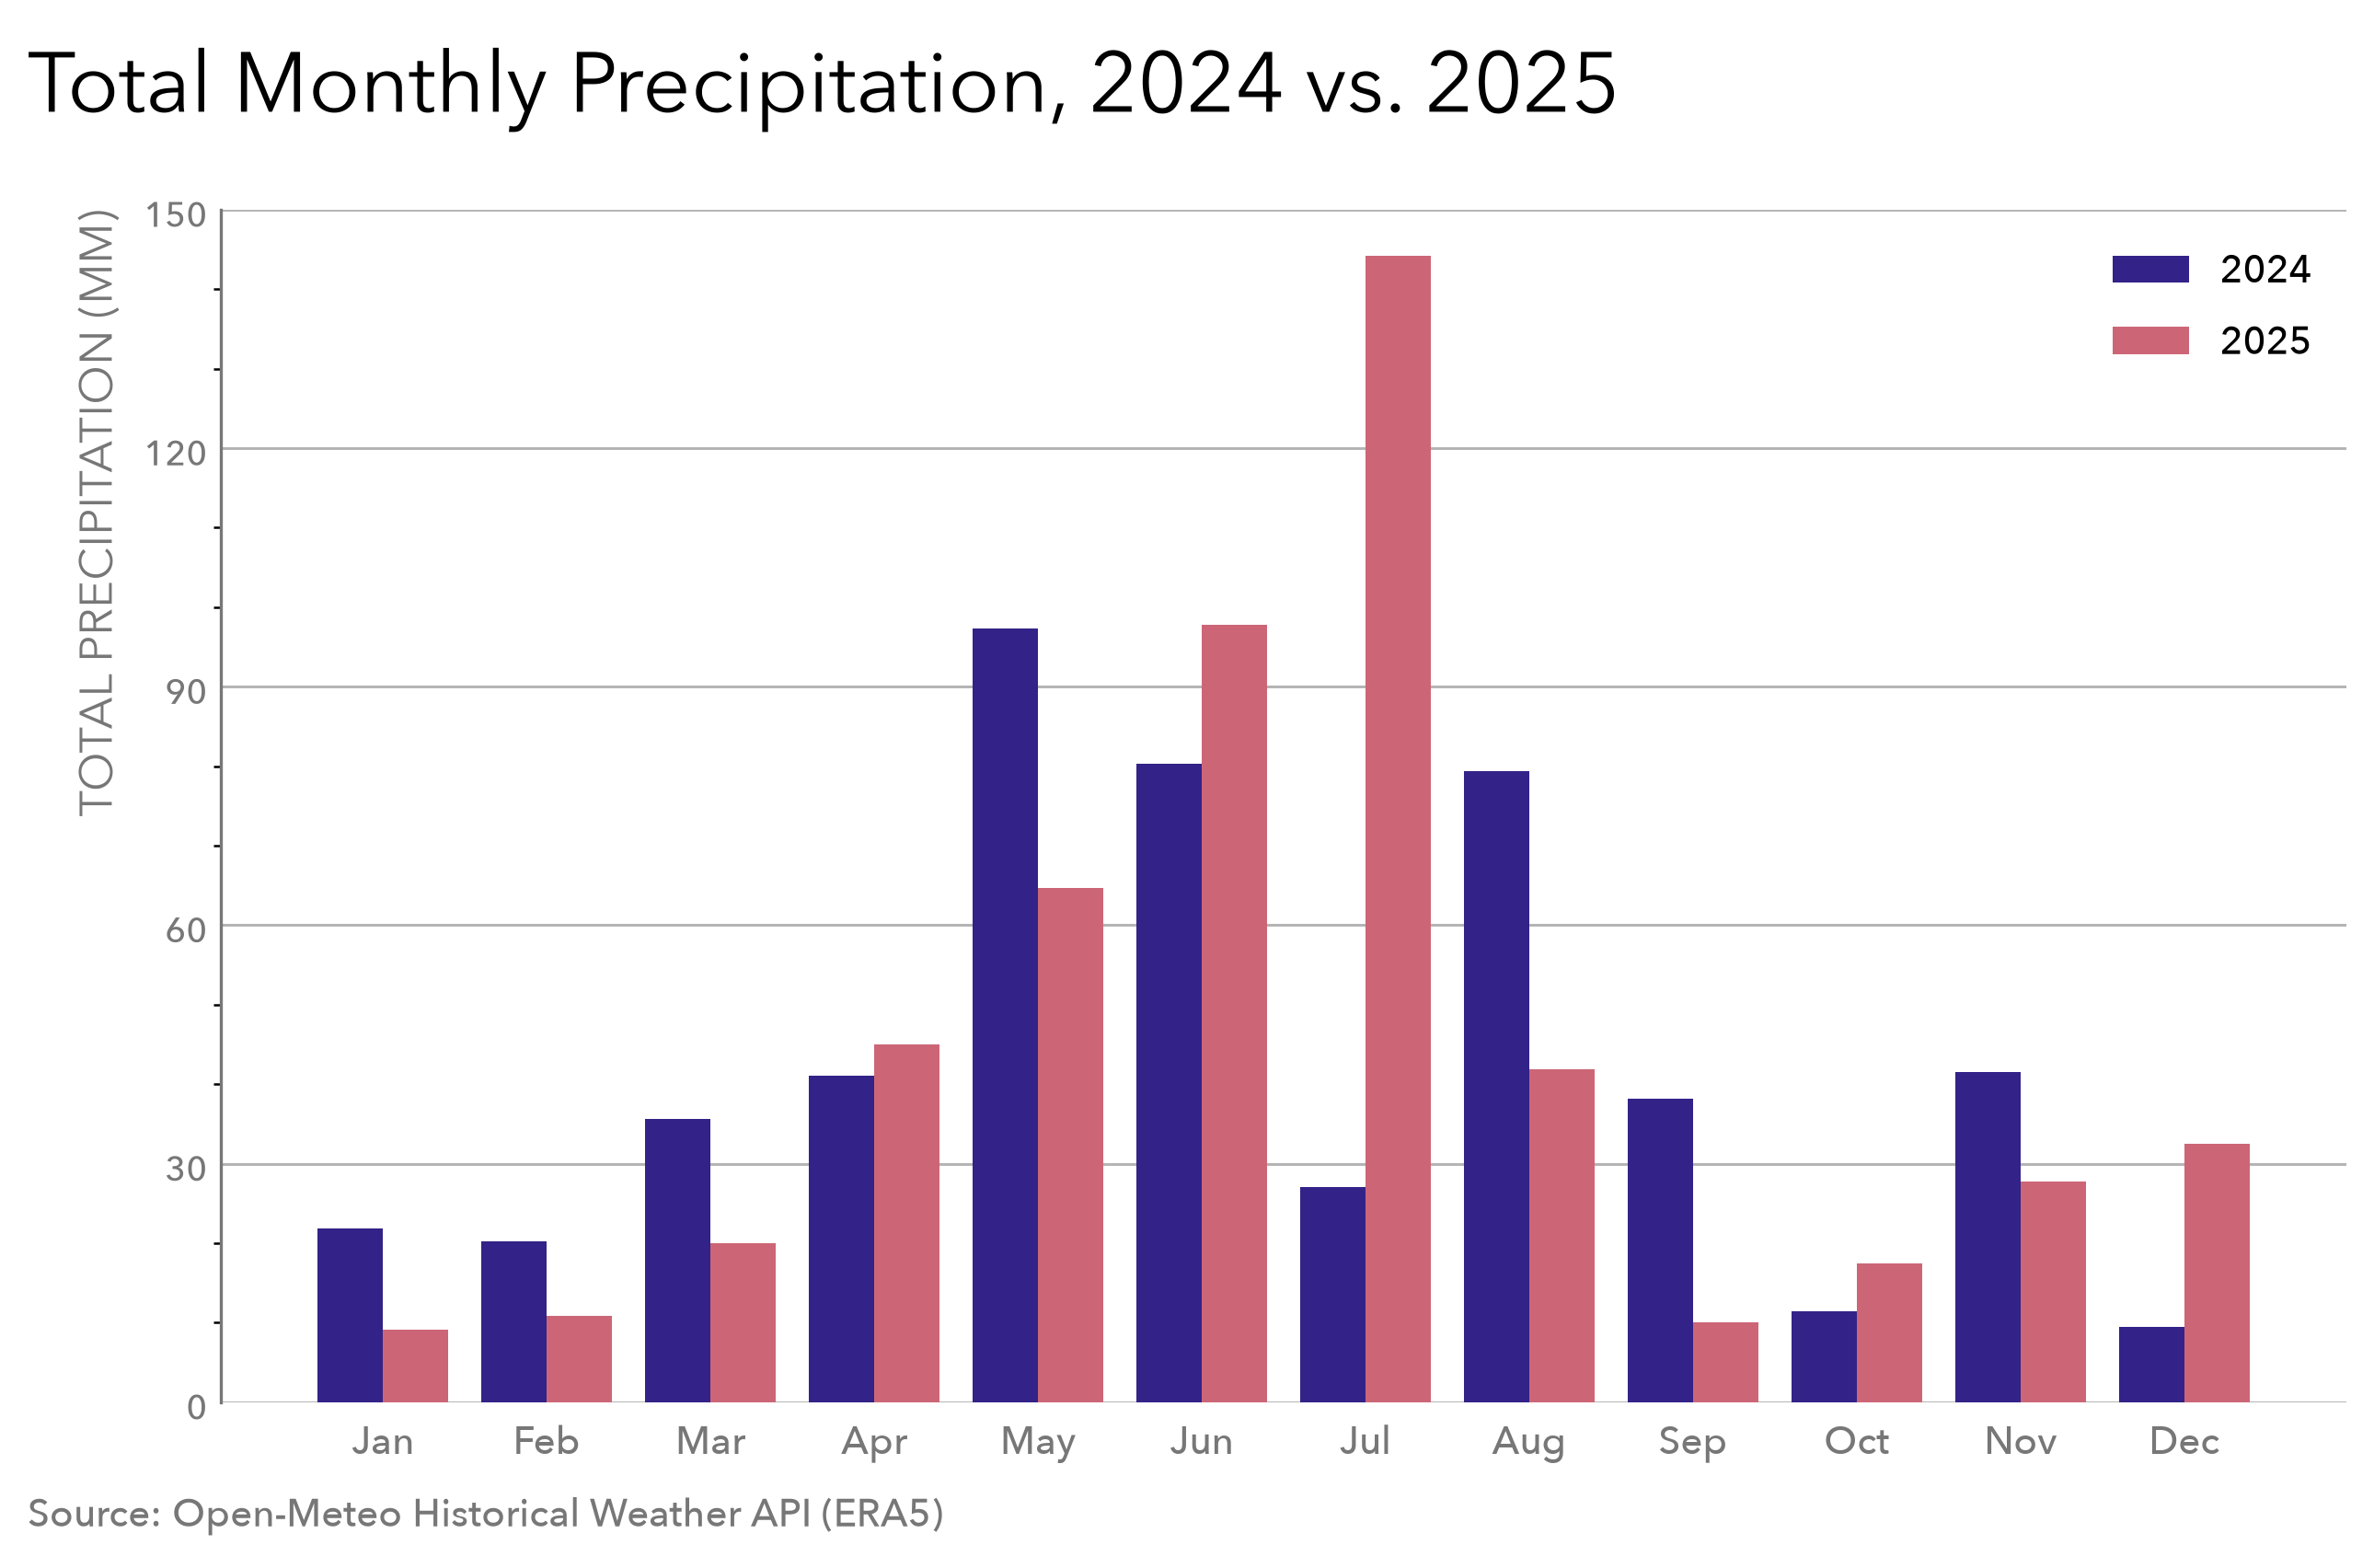

In [10]:
# Visualize

# Figure

plt.rcParams["font.family"] = "Avenir Next"
plt.rcParams["font.weight"] = 500

fig, ax = plt.subplots(figsize = (10, 6), dpi = 300)

fig.subplots_adjust(
    left = 0.13,
    right = 0.90,
    top = 0.83,
    bottom = 0.11
)

STRUCTURE = "#777777"
GRID = "#B3B3B3"
COLOR_2024 = "#332288"
COLOR_2025 = "#CC6677"

# Plot

bars_2024 = ax.bar(output_df["month"], output_df[2024], width = -0.4, align = "edge", color = COLOR_2024, label = "2024")
bars_2025 = ax.bar(output_df["month"], output_df[2025], width = 0.4, align = "edge", color = COLOR_2025, label = "2025")

# Scale & Axes

ax.set_ylim(0, 150)

ax.set_ylabel("TOTAL PRECIPITATION (MM)", loc = "top", fontsize = 12, fontweight = 400, color = STRUCTURE)

# Ticks

ax.set_yticks([0, 30, 60, 90, 120, 150])
ax.set_yticks([10, 20, 40, 50, 70, 80, 100, 110, 130, 140], minor = True)

ax.tick_params(axis = "x", labelsize = 10, length = 0, labelcolor = STRUCTURE)
ax.tick_params(axis = "y", labelsize = 9, length = 0, labelcolor = STRUCTURE)

# Styling

ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.spines["left"].set_color(STRUCTURE)
ax.spines["left"].set_linewidth(0.8)

ax.legend(frameon=False, ncol=1,fontsize=10)

ax.set_axisbelow(True)
ax.grid(axis = "y",which = "major", color = GRID, linewidth=0.7)

# Composition

fig.suptitle("Total Monthly Precipitation, 2024 vs. 2025", x = 0.06, y = 0.94, ha = "left", va = "top", fontweight = 400, fontsize = 22)

fig.text(0.06, 0.035, "Source: Open-Meteo Historical Weather API (ERA5)", fontsize = 10, color = STRUCTURE)

# Output
fig.savefig("outputs/monthly-total-precipitation-comparison-2024-vs-2025.svg", bbox_inches = "tight", pad_inches = 0.1)
plt.show()